In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer

import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: mps


In [2]:
from torchvision import datasets, transforms
from experiments.datasets import Toy1DRegressionDataset

toy_1d = Toy1DRegressionDataset()
train_dataset = toy_1d.train_dataset
test_dataset = toy_1d.val_dataset

In [12]:
mlp_base = MLP(
    input_dim=1,
    hidden_dims=[16,16,16],
    output_dim=1
)
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

LOADER_SEED = 645297
batch_size = 128
n_epoch = 5
K_RANGE = [16,20,32,40]

In [13]:
model_adam = MLP(input_dim=1, hidden_dims=[16,16,16], output_dim=1)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

optimizer = torch.optim.Adam(model_adam.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

Using device cpu


100%|██████████| 5/5 [00:00<00:00, 14.58it/s]


In [19]:
device = 'cpu'
svd_info = {K:{} for K in K_RANGE}
losses_svd = {K:{}  for K in K_RANGE}
for K in K_RANGE:
    for METHOD in ['randomized','lobpcg']:
        print(f"K={K}, METHOD={METHOD}")
        model_svd = MLP(input_dim=1, hidden_dims=[16,16,16], output_dim=1)
        model_svd.load_state_dict(init_state)
        model_svd = model_svd.to(device)

        def loss_fn(pred,y):
            loss = (pred - y)**2
            loss = loss.sum(dim=-1)
            return loss

        RTOL = 1e-3
        LR = 0.1

        model_svd = FunctionalModelJac(model_svd, loss_fn, device=device)
        optimizer = SVDOptimizer(model_svd,lr=LR,k=K,rtol=RTOL,track_svd_info=True, svd_mode=METHOD, power_iterations=1)


        train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=True)
        test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

        model_svd, losses_run, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
        svd_info[K][METHOD] = optimizer.svd_info
        losses_svd[K][METHOD] = losses_run

        torch.compiler.reset()

K=16, METHOD=randomized


100%|██████████| 5/5 [00:02<00:00,  1.69it/s]


K=16, METHOD=lobpcg


100%|██████████| 5/5 [00:01<00:00,  3.59it/s]


K=20, METHOD=randomized


...

100%|██████████| 5/5 [00:01<00:00,  3.17it/s]


K=40, METHOD=randomized


100%|██████████| 5/5 [00:03<00:00,  1.52it/s]


K=40, METHOD=lobpcg


100%|██████████| 5/5 [00:01<00:00,  2.68it/s]


### Compare

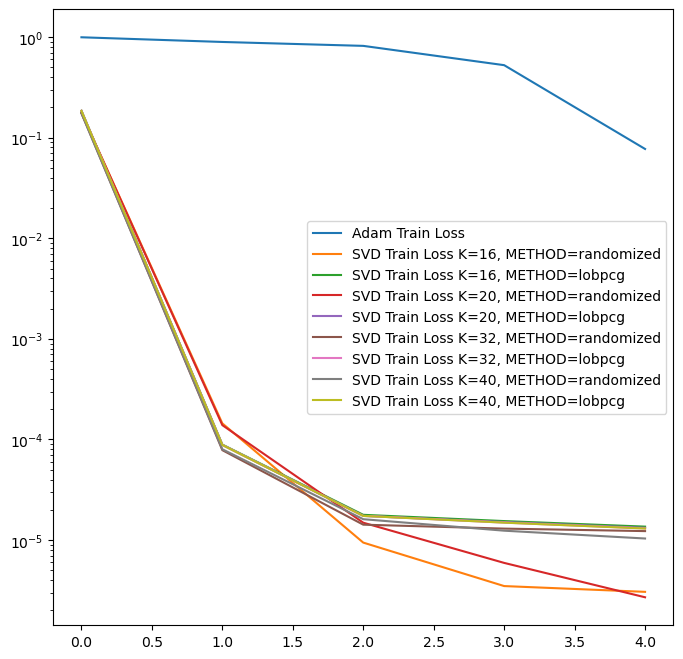

In [20]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['train'])), losses_adam['train'], label='Adam Train Loss')
for i,K in enumerate(K_RANGE):
    for j,METHOD in enumerate(['randomized','lobpcg']):
        ax.plot(np.arange(len(losses_svd[K][METHOD]['train'])), losses_svd[K][METHOD]['train'], label=f'SVD Train Loss K={K}, METHOD={METHOD}')
plt.yscale('log')
plt.legend()

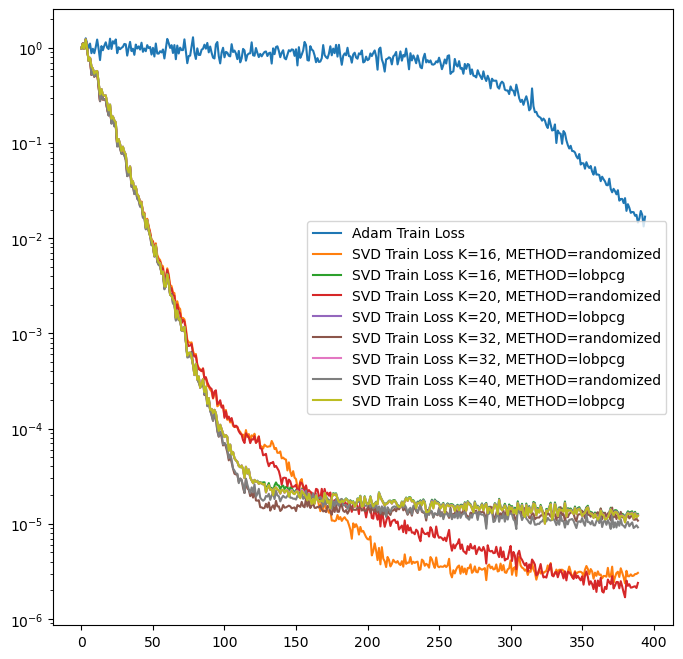

In [22]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['train_batch'])), losses_adam['train_batch'], label='Adam Train Loss')
for K in K_RANGE:
    for METHOD in ['randomized','lobpcg']:
        ax.plot(np.arange(len(losses_svd[K][METHOD]['train_batch'])), losses_svd[K][METHOD]['train_batch'], label=f'SVD Train Loss K={K}, METHOD={METHOD}')
plt.yscale('log')
plt.legend()

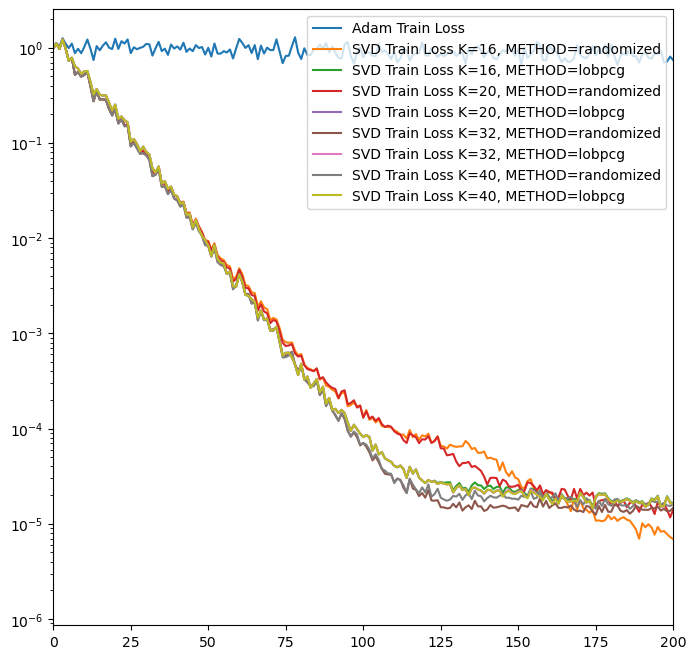

In [23]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['train_batch'])), losses_adam['train_batch'], label='Adam Train Loss')
for K in K_RANGE:
    for METHOD in ['randomized','lobpcg']:
        ax.plot(np.arange(len(losses_svd[K][METHOD]['train_batch'])), losses_svd[K][METHOD]['train_batch'], label=f'SVD Train Loss K={K}, METHOD={METHOD}')
plt.yscale('log')
ax.set_xlim(0,200)
plt.legend()

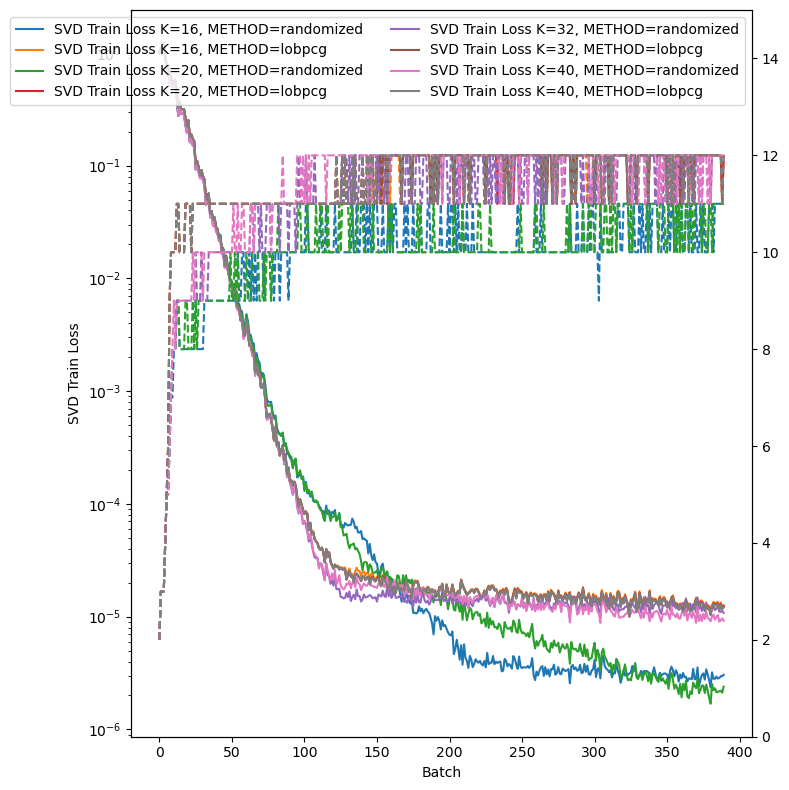

In [26]:
fig, ax1 = plt.subplots(figsize=(8,8))

plots = []
for i,K in enumerate(K_RANGE):
    for j, METHOD in enumerate(['randomized','lobpcg']):
        p1 = ax1.plot(np.arange(len(losses_svd[K][METHOD]['train_batch'])), losses_svd[K][METHOD]['train_batch'], f'C{2*i+j}-', label=f'SVD Train Loss K={K}, METHOD={METHOD}')
        plots.append(p1[0])
ax1.set_xlabel('Batch')
ax1.set_ylabel('SVD Train Loss')
ax1.set_yscale('log')
ax1.legend()

ax2 = ax1.twinx()
for i,K in enumerate(K_RANGE):
    for j, METHOD in enumerate(['randomized','lobpcg']):
        p2 = ax2.plot(np.arange(len(svd_info[K][METHOD]['num_nonzero_svs'])), svd_info[K][METHOD]['num_nonzero_svs'], f'C{2*i+j}--',label=f'Number of Nonzero SVs K={K}')
ax2.set_ylim(0,15)

ax1.legend(handles=plots,ncol=2)
plt.tight_layout()